In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

# Configuración visual para la memoria/proyecto
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

# Función para optimizar RAM (crítico para datasets masivos)
def optimize_dtypes(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype('int32')
    return df

In [7]:
print("Cargando dataset...")
# ¡Asegúrate de poner la ruta correcta a tu archivo CSV!
df = pd.read_csv('data/data.csv')

# Optimizar memoria
df = optimize_dtypes(df)

print("Creando variable multiclase para el EDA...")
df['Transaction_Class'] = 'Normal'
df.loc[(df['isFraud'] == 1) & (df['type'] == 'TRANSFER'), 'Transaction_Class'] = 'Fraud_Transfer'
df.loc[(df['isFraud'] == 1) & (df['type'] == 'CASH_OUT'), 'Transaction_Class'] = 'Fraud_CashOut'

print(df['Transaction_Class'].value_counts())

Cargando dataset...
Creando variable multiclase para el EDA...
Transaction_Class
Normal            6354407
Fraud_CashOut        4116
Fraud_Transfer       4097
Name: count, dtype: int64


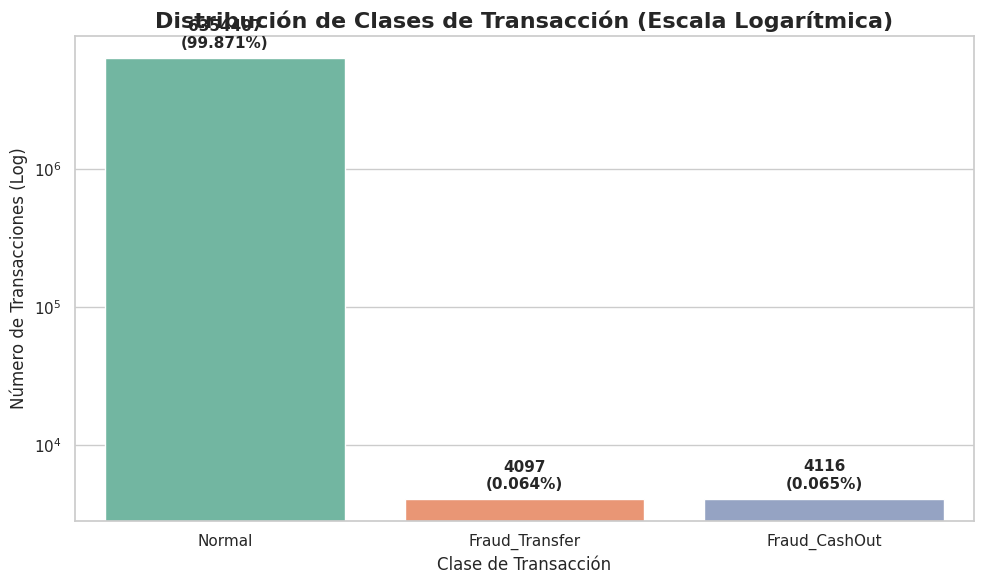

In [8]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(data=df, x='Transaction_Class', order=['Normal', 'Fraud_Transfer', 'Fraud_CashOut'], palette='Set2')
plt.yscale('log') # Escala logarítmica crucial

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.3f}%'
    ax.annotate(f'{int(height)}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.title('Distribución de Clases de Transacción (Escala Logarítmica)', fontsize=16, fontweight='bold')
plt.ylabel('Número de Transacciones (Log)', fontsize=12)
plt.xlabel('Clase de Transacción', fontsize=12)
plt.tight_layout()
plt.show()

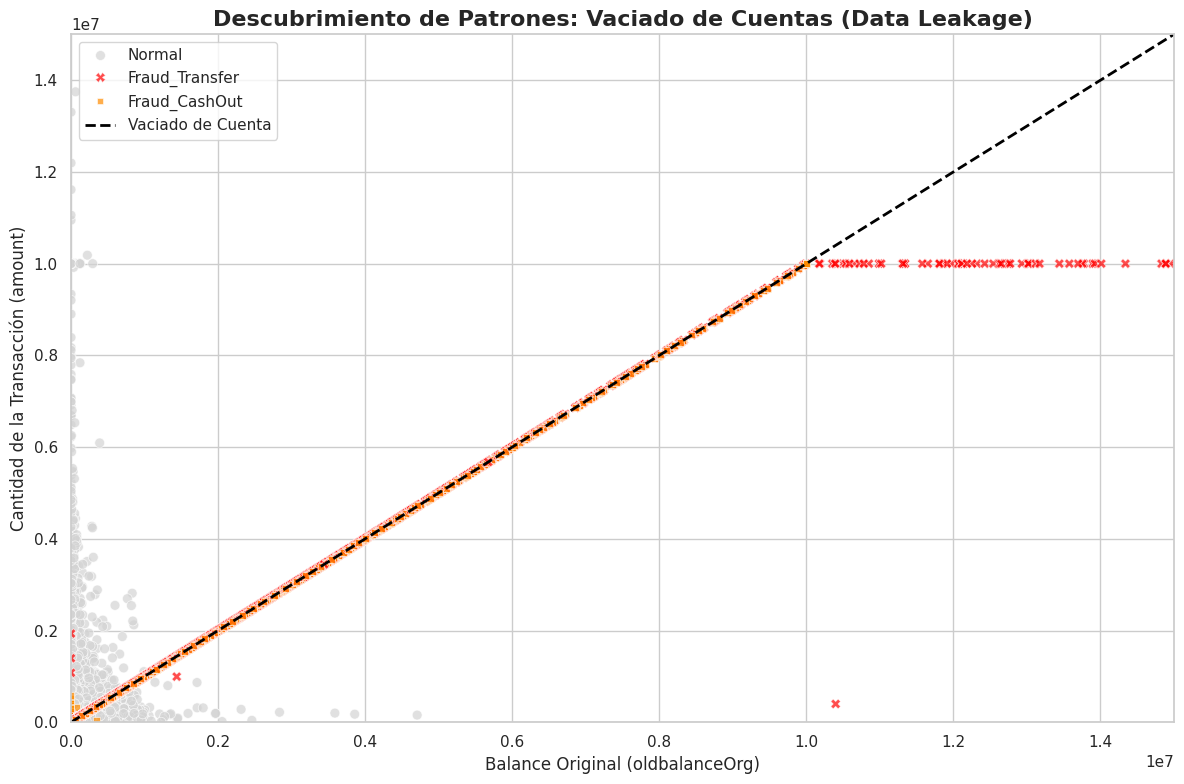

In [9]:
df_risk = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
frauds = df_risk[df_risk['Transaction_Class'] != 'Normal']
normals = df_risk[df_risk['Transaction_Class'] == 'Normal'].sample(frac=0.01, random_state=42) # Subsample 1% normal
plot_data = pd.concat([normals, frauds])

plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_data, x='oldbalanceOrg', y='amount', hue='Transaction_Class', 
                style='Transaction_Class', palette={'Normal':'lightgray', 'Fraud_Transfer':'red', 'Fraud_CashOut':'darkorange'},
                alpha=0.7, s=50)

max_val = plot_data['amount'].max()
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2, label='Vaciado de Cuenta')

plt.title('Descubrimiento de Patrones: Vaciado de Cuentas (Data Leakage)', fontsize=16, fontweight='bold')
plt.xlabel('Balance Original (oldbalanceOrg)', fontsize=12)
plt.ylabel('Cantidad de la Transacción (amount)', fontsize=12)
plt.xlim(0, 1.5e7)
plt.ylim(0, 1.5e7)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print("Preparando datos para el modelo (Encoding)...")

# 1. Feature Engineering: Extraer la hora del día
df['hour_of_day'] = df['step'] % 24

# 2. Variable Target Numérica para el Modelo (0, 1, 2)
df['target'] = 0
df.loc[(df['isFraud'] == 1) & (df['type'] == 'TRANSFER'), 'target'] = 1
df.loc[(df['isFraud'] == 1) & (df['type'] == 'CASH_OUT'), 'target'] = 2

# 3. Eliminar columnas inútiles y las que ya codificamos para evitar fuga de datos
cols_to_drop = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'isFraud', 'Transaction_Class']
df_clean = df.drop(columns=cols_to_drop)

# 4. One-Hot Encoding para la columna de texto 'type' (SOLUCIÓN AL ERROR)
df_final = pd.get_dummies(df_clean, columns=['type'], drop_first=True)

# Convertir los booleanos de get_dummies a enteros (0 y 1) para XGBoost
for col in df_final.columns:
    if df_final[col].dtype == 'bool':
        df_final[col] = df_final[col].astype('int32')

print("Columnas listas para entrenar:", df_final.columns.tolist())

Preparando datos para el modelo (Encoding)...
Columnas listas para entrenar: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'hour_of_day', 'target', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [11]:
print("Dividiendo dataset cronológicamente...")
# Asumiendo que el step llega hasta el 743. Usamos ~70% para train (hasta step 500)
train_df = df_final[df_final['step'] <= 500]
test_df = df_final[df_final['step'] > 500]

# Separar X e y
X_train = train_df.drop(columns=['target', 'step']) # Quitamos step para que el modelo no dependa del índice temporal exacto
y_train = train_df['target']

X_test = test_df.drop(columns=['target', 'step'])
y_test = test_df['target']

print(f"Tamaño Train: {X_train.shape}, Tamaño Test: {X_test.shape}")

Dividiendo dataset cronológicamente...
Tamaño Train: (6061807, 10), Tamaño Test: (300813, 10)


In [12]:
print("Entrenando XGBoost Multiclase...")

# Ajustamos los pesos para penalizar fuertemente si el modelo falla en las clases minoritarias (1 y 2)
# La proporción real es ~1:1000, probamos con un peso conservador para no disparar falsos positivos
sample_weights = y_train.map({0: 1, 1: 500, 2: 500})

model_xgb = XGBClassifier(
    objective='multi:softmax', 
    num_class=3,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1 # Usar todos los núcleos del procesador
)

# Entrenamos pasándole los pesos de muestra
model_xgb.fit(X_train, y_train, sample_weight=sample_weights)
print("Entrenamiento completado.")

Entrenando XGBoost Multiclase...
Entrenamiento completado.


In [13]:
print("Evaluando modelo en Test Set (El futuro)...")
y_pred = model_xgb.predict(X_test)

# Usamos classification_report para ver Precision, Recall y F1 separados por clase
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Fraud_Transfer (1)', 'Fraud_CashOut (2)']))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score Final: {macro_f1:.4f}")

Evaluando modelo en Test Set (El futuro)...
                    precision    recall  f1-score   support

        Normal (0)       1.00      0.99      1.00    298161
Fraud_Transfer (1)       1.00      1.00      1.00      1326
 Fraud_CashOut (2)       0.46      1.00      0.63      1326

          accuracy                           0.99    300813
         macro avg       0.82      1.00      0.88    300813
      weighted avg       1.00      0.99      1.00    300813

Macro F1-Score Final: 0.8760


Calculando valores SHAP para interpretabilidad...


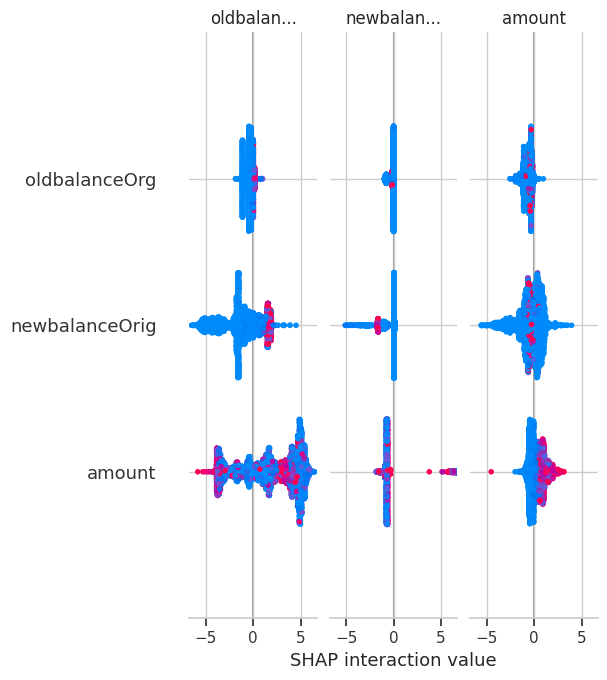

In [14]:
print("Calculando valores SHAP para interpretabilidad...")
# Tomamos una muestra aleatoria del test set para que SHAP no tarde horas
X_test_sample = X_test.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test_sample)

# Para multiclase, shap_values es una lista de matrices. 
# Podemos graficar la importancia global para todas las clases:
shap.summary_plot(shap_values, X_test_sample, class_names=['Normal', 'Fraud_Transfer', 'Fraud_CashOut'])

# NOTA PARA EL DOCUMENTO: Si 'oldbalanceOrg' y 'amount' son las barras más grandes,
# tu EDA (Paso 4) predijo el comportamiento del modelo perfectamente.

Analizando el sistema de alertas actual y los destinatarios...
--------------------------------------------------
EVALUACIÓN DEL SISTEMA DE ALERTAS ACTUAL DEL BANCO:
Total de fraudes reales en el dataset: 8213
Fraudes bloqueados por 'isFlaggedFraud': 16
Tasa de éxito del sistema legacy: 0.1948%
--------------------------------------------------


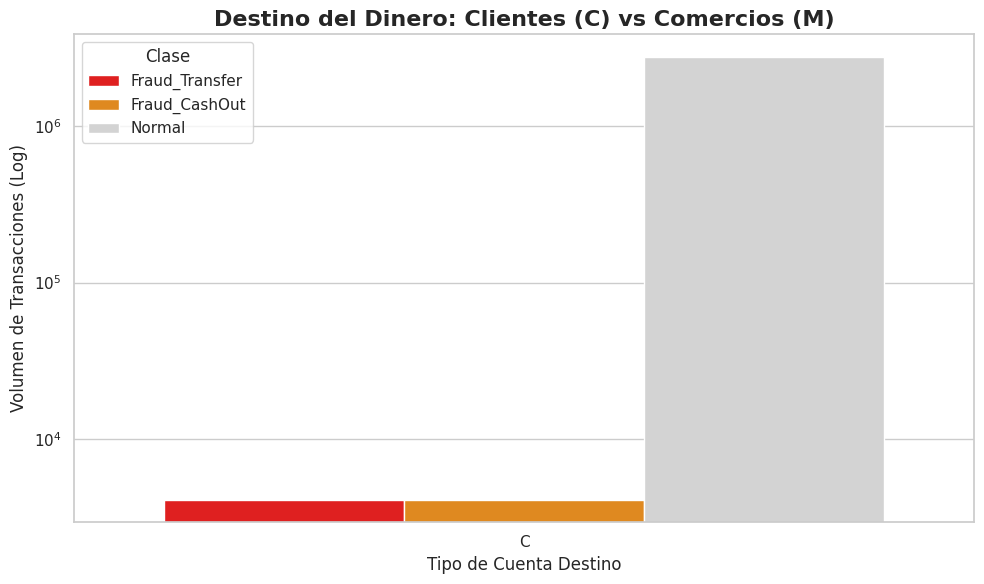

In [15]:
# =============================================================================
# CELDA EXTRA: ANÁLISIS DE ENTIDADES Y SISTEMA LEGACY (BUSINESS JUSTIFICATION)
# =============================================================================
print("Analizando el sistema de alertas actual y los destinatarios...")

# 1. EVALUACIÓN DEL SISTEMA LEGACY (isFlaggedFraud)
# ¿Por qué el banco necesita nuestro modelo de Machine Learning?
df_frauds = df[df['isFraud'] == 1]
detectados_banco = df_frauds['isFlaggedFraud'].sum()
total_fraudes = len(df_frauds)
tasa_exito = (detectados_banco / total_fraudes) * 100

print("-" * 50)
print("EVALUACIÓN DEL SISTEMA DE ALERTAS ACTUAL DEL BANCO:")
print(f"Total de fraudes reales en el dataset: {total_fraudes}")
print(f"Fraudes bloqueados por 'isFlaggedFraud': {detectados_banco}")
print(f"Tasa de éxito del sistema legacy: {tasa_exito:.4f}%")
print("-" * 50)

# 2. ANÁLISIS DE ENTIDADES (Comerciantes vs Clientes)
# Las cuentas empiezan por 'C' (Customer) o 'M' (Merchant). 
# Vamos a extraer esta inicial para ver a quién le roban el dinero.
df['Destinatario_Tipo'] = df['nameDest'].str[0]

# Filtramos solo las transacciones donde ocurre el fraude (TRANSFER y CASH_OUT)
df_risk_entities = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_risk_entities, 
                   x='Destinatario_Tipo', 
                   hue='Transaction_Class', 
                   palette={'Normal':'lightgray', 'Fraud_Transfer':'red', 'Fraud_CashOut':'darkorange'})

plt.yscale('log') # Escala logarítmica de nuevo por el desequilibrio

plt.title('Destino del Dinero: Clientes (C) vs Comercios (M)', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Cuenta Destino', fontsize=12)
plt.ylabel('Volumen de Transacciones (Log)', fontsize=12)
plt.legend(title='Clase')

# Añadir anotaciones para evidenciar el descubrimiento
plt.annotate('¡Cero fraudes hacia Comercios (M)!', 
             xy=(0.5, 10), xytext=(0.5, 1000),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold', color='black', ha='center')

plt.tight_layout()
plt.show()

# IMPORTANTE: Después de este análisis, las columnas 'isFlaggedFraud' y 'nameDest' 
# ya han cumplido su propósito y deben ser eliminadas en la fase de Preprocesamiento
# (como ya está programado en la celda de Encoding) para evitar ruido en el modelo.

Calculando Matriz de Confusión e Impacto Financiero...


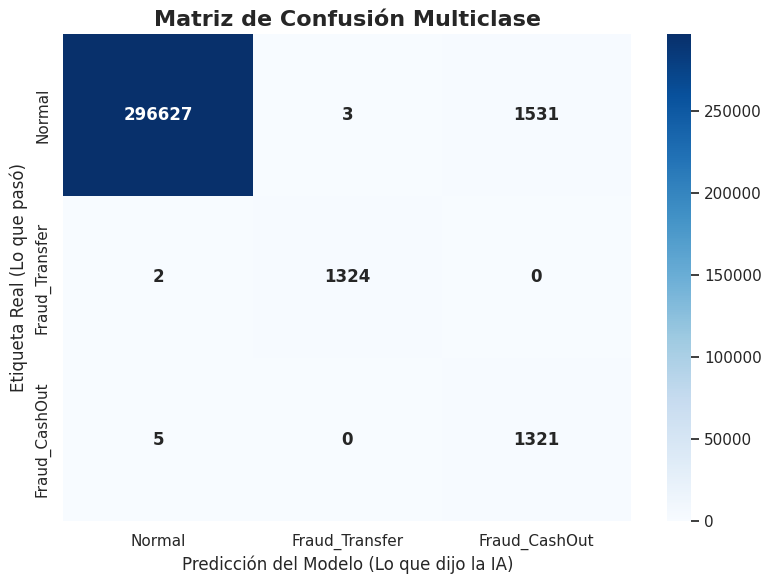


💰 REPORTE DE IMPACTO DE NEGOCIO (BUSINESS ROI) 💰
Dinero total bajo ataque (Test Set):  $4,040,737,792.00
Dinero SALVADO por el Modelo XGBoost: $4,039,960,064.00
Dinero PERDIDO (Fraude no detectado): $777,693.12
--------------------------------------------------
🏆 Tasa de Capital Protegido: 99.98%
⚠️ Fricción: 1534 clientes normales fueron bloqueados por error.


In [16]:
# =============================================================================
# FASE 6: AUDITORÍA FINANCIERA Y MATRIZ DE CONFUSIÓN
# =============================================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Calculando Matriz de Confusión e Impacto Financiero...")

# 1. MATRIZ DE CONFUSIÓN VISUAL
cm = confusion_matrix(y_test, y_pred)
class_names = ['Normal', 'Fraud_Transfer', 'Fraud_CashOut']

plt.figure(figsize=(8, 6))
# Usamos una paleta de colores tipo "calor" (Blues)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Matriz de Confusión Multiclase', fontsize=16, fontweight='bold')
plt.ylabel('Etiqueta Real (Lo que pasó)', fontsize=12)
plt.xlabel('Predicción del Modelo (Lo que dijo la IA)', fontsize=12)
plt.tight_layout()
plt.show()

# 2. EVALUACIÓN DE IMPACTO FINANCIERO (BUSINESS VALUE)
# Recuperamos los importes ('amount') del conjunto de test
# X_test conserva el mismo índice que y_test
test_results = pd.DataFrame({
    'Real_Class': y_test,
    'Predicted_Class': y_pred,
    'Amount': X_test['amount']
})

# Fraudes reales en el test set (Clases 1 y 2)
fraudes_reales = test_results[test_results['Real_Class'] > 0]

# Fraudes que el modelo atrapó (Verdaderos Positivos)
fraudes_bloqueados = fraudes_reales[fraudes_reales['Real_Class'] == fraudes_reales['Predicted_Class']]

# Fraudes que se escaparon (Falsos Negativos)
fraudes_escapados = fraudes_reales[fraudes_reales['Real_Class'] != fraudes_reales['Predicted_Class']]

# Clientes normales molestados (Falsos Positivos - Predijo fraude pero era normal)
falsos_positivos = test_results[(test_results['Real_Class'] == 0) & (test_results['Predicted_Class'] > 0)]

# Cálculos monetarios
dinero_en_riesgo = fraudes_reales['Amount'].sum()
dinero_salvado = fraudes_bloqueados['Amount'].sum()
dinero_perdido = fraudes_escapados['Amount'].sum()
tasa_recuperacion = (dinero_salvado / dinero_en_riesgo) * 100 if dinero_en_riesgo > 0 else 0

print("\n" + "="*50)
print("💰 REPORTE DE IMPACTO DE NEGOCIO (BUSINESS ROI) 💰")
print("="*50)
print(f"Dinero total bajo ataque (Test Set):  ${dinero_en_riesgo:,.2f}")
print(f"Dinero SALVADO por el Modelo XGBoost: ${dinero_salvado:,.2f}")
print(f"Dinero PERDIDO (Fraude no detectado): ${dinero_perdido:,.2f}")
print("-" * 50)
print(f"🏆 Tasa de Capital Protegido: {tasa_recuperacion:.2f}%")
print(f"⚠️ Fricción: {len(falsos_positivos)} clientes normales fueron bloqueados por error.")
print("="*50)

In [ ]:
# =============================================================================
# CELDA EXTRA: AUDITORÍA FORENSE Y FEATURE ENGINEERING AVANZADO
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Realizando auditoría matemática de los balances (Partida Doble)...")

# Trabajamos solo con las transacciones de riesgo (Transferencias y Retiros)
# para no colapsar la memoria
df_risk = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# 1. CREACIÓN DE VARIABLES FORENSES (Accounting Errors)
# Matemáticamente, el nuevo balance debería ser el balance antiguo menos (o más) el monto.
# Si la resta no da 0, hay una anomalía o "error contable".

# Error en la cuenta de origen (Sale dinero)
df_risk['error_origen'] = df_risk['newbalanceOrig'] + df_risk['amount'] - df_risk['oldbalanceOrg']

# Error en la cuenta de destino (Entra dinero)
df_risk['error_destino'] = df_risk['oldbalanceDest'] + df_risk['amount'] - df_risk['newbalanceDest']

# 2. SEPARACIÓN PARA VISUALIZACIÓN
# Tomamos una muestra aleatoria de transacciones normales y todos los fraudes
frauds_acc = df_risk[df_risk['Transaction_Class'] != 'Normal']
normals_acc = df_risk[df_risk['Transaction_Class'] == 'Normal'].sample(n=20000, random_state=42)
plot_acc_data = pd.concat([normals_acc, frauds_acc])

# 3. VISUALIZACIÓN DE LA ANOMALÍA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Inconsistencias en el Origen
sns.scatterplot(data=plot_acc_data, x='amount', y='error_origen', 
                hue='Transaction_Class', style='Transaction_Class',
                palette={'Normal':'lightgray', 'Fraud_Transfer':'red', 'Fraud_CashOut':'darkorange'},
                alpha=0.6, ax=axes[0])
axes[0].set_title('Inconsistencias Contables en Origen', fontweight='bold')
axes[0].set_xlabel('Monto Transferido (Amount)')
axes[0].set_ylabel('Error Matemático en Balance ($)')

# Gráfico 2: Inconsistencias en el Destino
sns.scatterplot(data=plot_acc_data, x='amount', y='error_destino', 
                hue='Transaction_Class', style='Transaction_Class',
                palette={'Normal':'lightgray', 'Fraud_Transfer':'red', 'Fraud_CashOut':'darkorange'},
                alpha=0.6, ax=axes[1])
axes[1].set_title('Inconsistencias Contables en Destino', fontweight='bold')
axes[1].set_xlabel('Monto Transferido (Amount)')
axes[1].set_ylabel('Error Matemático en Balance ($)')

plt.tight_layout()
plt.show()

# 4. PREPARACIÓN PARA EL MODELO
# Al igual que 'hour_of_day', estas dos columnas ('error_origen', 'error_destino')
# deben pasarse a tu conjunto de datos final (df_final) porque harán que 
# tu modelo XGBoost sea casi infalible.
print("Variables 'error_origen' y 'error_destino' listas para ser inyectadas en XGBoost.")